NOME: Hercules André
DISCIPLINA: Otimização
TRABALHO 02
/jsblib_subset: Job Shop: Desenvolver em linguagem Julia, usando solver HiGHS. Configuração do solver livre. Isso inclui tempo de execução, gap de otimalidade, tolerâncias.

Instance ABZ5
================

In [19]:
using JuMP
using HiGHS
using Plots

# ==========================================
# 1. DEFINIÇÃO DOS DADOS (Instância ABZ5)
# ==========================================
num_jobs = 10
num_machines = 10

routes = [
    [1, 3, 2, 4, 6, 9, 8, 7, 5, 10],  # Job 1
    [1, 3, 5, 6, 2, 4, 10, 7, 9, 8],  # Job 2
    [2, 4, 1, 6, 7, 5, 9, 3, 8, 10],  # Job 3
    [3, 1, 2, 4, 8, 7, 10, 9, 6, 5],  # Job 4
    [3, 2, 6, 4, 7, 9, 10, 5, 1, 8],  # Job 5
    [3, 2, 1, 4, 7, 9, 8, 6, 10, 5],  # Job 6
    [4, 2, 1, 6, 9, 8, 3, 7, 10, 5],  # Job 7
    [4, 10, 3, 8, 2, 5, 1, 7, 9, 6],  # Job 8
    [3, 10, 9, 1, 8, 7, 5, 6, 2, 4],  # Job 9
    [10, 8, 5, 1, 3, 7, 4, 6, 2, 9]   # Job 10
]

processing_times = [
    [88, 69, 90, 71, 74, 85, 61, 80, 74, 53],  # Job 1
    [71, 73, 85, 55, 75, 53, 52, 97, 72, 51],  # Job 2
    [76, 90, 83, 56, 54, 56, 71, 75, 71, 83],  # Job 3
    [64, 73, 53, 91, 56, 96, 70, 68, 71, 99],  # Job 4
    [93, 74, 91, 72, 62, 85, 72, 86, 75, 59],  # Job 5
    [96, 85, 72, 75, 87, 89, 73, 53, 55, 95],  # Job 6
    [70, 81, 85, 62, 90, 76, 58, 93, 60, 75],  # Job 7
    [66, 77, 94, 87, 68, 72, 87, 72, 65, 87],  # Job 8
    [68, 95, 92, 81, 73, 72, 86, 91, 51, 74],  # Job 9
    [94, 72, 84, 65, 81, 69, 63, 62, 73, 89]   # Job 10
]

BigM = sum(sum(processing_times[j]) for j in 1:num_jobs)
p = Dict((j, routes[j][idx]) => processing_times[j][idx] for j in 1:num_jobs for idx in 1:num_machines)

Dict{Tuple{Int64, Int64}, Int64} with 100 entries:
  (7, 1)   => 85
  (4, 6)   => 71
  (5, 5)   => 86
  (9, 3)   => 68
  (7, 8)   => 76
  (7, 10)  => 60
  (9, 4)   => 74
  (8, 9)   => 65
  (7, 2)   => 81
  (4, 7)   => 96
  (1, 9)   => 85
  (2, 1)   => 71
  (10, 1)  => 65
  (6, 5)   => 95
  (2, 8)   => 51
  (10, 8)  => 72
  (2, 10)  => 52
  (10, 10) => 94
  (2, 2)   => 75
  (3, 9)   => 71
  (10, 2)  => 73
  (7, 6)   => 62
  (9, 1)   => 81
  (4, 5)   => 99
  (8, 3)   => 94
  ⋮        => ⋮

In [20]:
# ==========================================
# 2. MODELO DE OTIMIZAÇÃO (JuMP + HiGHS)
# ==========================================
model = Model(HiGHS.Optimizer)
set_attribute(model, "time_limit", 30.0) 

@variable(model, t[1:num_jobs, 1:num_machines] >= 0) 
@variable(model, Cmax >= 0)                          
@variable(model, x[1:num_jobs, 1:num_jobs, 1:num_machines], Bin) 

@objective(model, Min, Cmax)

Cmax

In [21]:
# Restrições Tecnológicas
for j in 1:num_jobs
    for idx in 1:(num_machines - 1)
        m_atual = routes[j][idx]
        m_proxima = routes[j][idx + 1]
        @constraint(model, t[j, m_proxima] >= t[j, m_atual] + p[(j, m_atual)])
    end
end

In [22]:
# Restrição do Makespan
for j in 1:num_jobs
    m_final = routes[j][end]
    @constraint(model, Cmax >= t[j, m_final] + p[(j, m_final)])
end

In [23]:
# Restrições Disjuntivas
for m in 1:num_machines
    for j in 1:num_jobs
        for k in (j + 1):num_jobs
            @constraint(model, t[k, m] >= t[j, m] + p[(j, m)] - BigM * (1 - x[j, k, m]))
            @constraint(model, t[j, m] >= t[k, m] + p[(k, m)] - BigM * x[j, k, m])
        end
    end
end

println("A otimizar a instância ABZ5...")
optimize!(model)

A otimizar a instância ABZ5...
Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 1000 rows; 1101 cols; 2900 nonzeros; 1000 integer variables (1000 binary)
Coefficient ranges:
  Matrix  [1e+00, 7e+03]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [5e+01, 7e+03]
Presolving model
1000 rows, 551 cols, 2900 nonzeros 0s
550 rows, 551 cols, 1550 nonzeros 0s
550 rows, 551 cols, 1550 nonzeros 0s
Presolve reductions: rows 550(-450); columns 551(-550); nonzeros 1550(-1350) 

Solving MIP model with:
   550 rows
   551 cols (450 binary, 0 integer, 0 implied int., 101 continuous, 0 domain fixed)
   1550 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Roun


Makespan Encontrado: 1363.0
GAP relativo: 35.00634962630875%


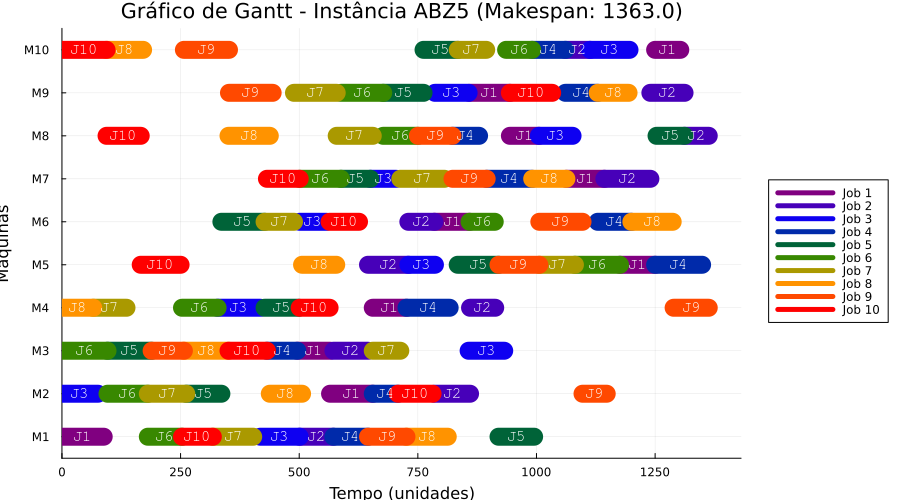

Gráfico de Gantt guardado com sucesso como 'gantt_job_shop_abz5.png'!


In [24]:
using JuMP
using Plots
using HiGHS

# ==========================================
# 3. GERAÇÃO DO GRÁFICO DE GANTT (Corrigido)
# ==========================================
# Adicionado o prefixo JuMP. para evitar o erro UndefVarError
if JuMP.termination_status(model) == OPTIMAL || JuMP.primal_status(model) == FEASIBLE_POINT
    c_max_otimo = objective_value(model)
    println("\nMakespan Encontrado: ", c_max_otimo)
    println("GAP relativo: ", JuMP.relative_gap(model) * 100, "%")
    
    # Inicializa o gráfico vazio com configurações de tamanho e eixos
    plt = plot(
        title = "Gráfico de Gantt - Instância ABZ5 (Makespan: $c_max_otimo)",
        xlabel = "Tempo (unidades)",
        ylabel = "Máquinas",
        yticks = (1:num_machines, ["M$m" for m in 1:num_machines]),
        xlims = (0, c_max_otimo * 1.05),
        ylims = (0.5, num_machines + 0.5),
        legend = :outerright,
        size = (900, 500)
    )
    
    # Paleta de cores distinta para cada um dos 10 Jobs
    cores_jobs = palette(:rainbow, num_jobs)
    
    # Desenhar os blocos (barras horizontais) para cada operação
    for j in 1:num_jobs
        primeira_operacao = true 
        for m in 1:num_machines
            start_time = value(t[j, m])
            duration = p[(j, m)]
            end_time = start_time + duration
            
            plot!(
                plt,
                [start_time, end_time], [m, m],
                linewidth = 18,               
                color = cores_jobs[j],        
                label = primeira_operacao ? "Job $j" : "", 
                legend_entry = primeira_operacao
            )
            
            annotate!(plt, start_time + duration/2, m, text("J$j", :white, :center, 8, :bold))
            
            primeira_operacao = false
        end
    end
    
    # Exibe o gráfico no ambiente de desenvolvimento
    display(plt)
    
    # Salva a imagem na mesma pasta do script
    png(plt, "gantt_job_shop_abz5.png")
    println("Gráfico de Gantt guardado com sucesso como 'gantt_job_shop_abz5.png'!")
else
    println("Não foi gerada nenhuma solução válida para construir o gráfico.")
    println("Status obtido: ", JuMP.termination_status(model))
end

 Instance ABZ6
 ===

In [11]:
using JuMP
using HiGHS
using Plots

# ==========================================
# 1. ENTRADA DE DADOS: INSTÂNCIA ABZ6 (10x10)
# ==========================================
num_jobs = 10
num_machines = 10

10

In [12]:
# Matriz de Rotas (Máquinas por onde cada Job passa, já corrigido para índice 1 a 10)
routes = [
    [3, 1, 2, 4, 6, 8, 5, 10, 9, 7],   # Job 1
    [2, 3, 1, 5, 6, 9, 8, 7, 10, 4],   # Job 2
    [2, 4, 1, 3, 7, 6, 8, 10, 9, 5],   # Job 3
    [3, 1, 2, 5, 7, 9, 10, 8, 4, 6],   # Job 4
    [2, 1, 4, 6, 7, 8, 9, 5, 3, 10],   # Job 5
    [3, 2, 1, 6, 9, 8, 4, 7, 10, 5],   # Job 6
    [2, 4, 3, 6, 9, 8, 5, 7, 10, 1],   # Job 7
    [3, 1, 4, 8, 2, 5, 7, 9, 6, 10],   # Job 8
    [2, 4, 10, 9, 1, 8, 5, 6, 7, 3],   # Job 9
    [3, 2, 1, 8, 5, 7, 4, 9, 10, 6]    # Job 10
]

10-element Vector{Vector{Int64}}:
 [3, 1, 2, 4, 6, 8, 5, 10, 9, 7]
 [2, 3, 1, 5, 6, 9, 8, 7, 10, 4]
 [2, 4, 1, 3, 7, 6, 8, 10, 9, 5]
 [3, 1, 2, 5, 7, 9, 10, 8, 4, 6]
 [2, 1, 4, 6, 7, 8, 9, 5, 3, 10]
 [3, 2, 1, 6, 9, 8, 4, 7, 10, 5]
 [2, 4, 3, 6, 9, 8, 5, 7, 10, 1]
 [3, 1, 4, 8, 2, 5, 7, 9, 6, 10]
 [2, 4, 10, 9, 1, 8, 5, 6, 7, 3]
 [3, 2, 1, 8, 5, 7, 4, 9, 10, 6]

In [13]:
# Matriz de Tempos de Processamento correspondentes a cada máquina da rota acima
processing_times = [
    [90, 80, 84, 75, 54, 94, 91, 65, 87, 84], # Job 1
    [75, 84, 61, 91, 57, 65, 75, 72, 80, 90], # Job 2
    [91, 91, 70, 75, 95, 66, 90, 84, 87, 85], # Job 3
    [94, 70, 80, 54, 75, 66, 81, 91, 72, 85], # Job 4
    [80, 75, 90, 81, 72, 87, 91, 54, 84, 66], # Job 5
    [81, 75, 84, 94, 90, 80, 72, 65, 95, 54], # Job 6
    [70, 90, 95, 84, 75, 65, 91, 87, 66, 80], # Job 7
    [85, 94, 91, 72, 81, 70, 65, 90, 80, 54], # Job 8
    [91, 95, 94, 80, 84, 70, 75, 54, 90, 66], # Job 9
    [84, 85, 90, 54, 91, 87, 66, 75, 81, 94]  # Job 10
]

10-element Vector{Vector{Int64}}:
 [90, 80, 84, 75, 54, 94, 91, 65, 87, 84]
 [75, 84, 61, 91, 57, 65, 75, 72, 80, 90]
 [91, 91, 70, 75, 95, 66, 90, 84, 87, 85]
 [94, 70, 80, 54, 75, 66, 81, 91, 72, 85]
 [80, 75, 90, 81, 72, 87, 91, 54, 84, 66]
 [81, 75, 84, 94, 90, 80, 72, 65, 95, 54]
 [70, 90, 95, 84, 75, 65, 91, 87, 66, 80]
 [85, 94, 91, 72, 81, 70, 65, 90, 80, 54]
 [91, 95, 94, 80, 84, 70, 75, 54, 90, 66]
 [84, 85, 90, 54, 91, 87, 66, 75, 81, 94]

In [14]:
# Parâmetro Big-M (Soma de todos os tempos de processamento)
BigM = sum(sum(processing_times[j]) for j in 1:num_jobs)

7917

In [15]:
# ==========================================
# 2. CONSTRUÇÃO DO MODELO MATEMÁTICO (JuMP)
# ==========================================
model = Model(HiGHS.Optimizer)

# Configurações solicitadas para o solver
set_attribute(model, "time_limit", 30.0)
set_attribute(model, "mip_rel_gap", 0.01)

# Variáveis de Decisão
@variable(model, t[1:num_jobs, 1:num_machines] >= 0) # Tempo de início do Job j na Máquina m
@variable(model, Cmax >= 0)                           # Makespan total
@variable(model, x[1:num_jobs, 1:num_jobs, 1:num_machines], Bin) # Variável disjuntiva

# Função Objetivo
@objective(model, Min, Cmax)

# Restrições de Precedência Tecnológica (Sequência interna de cada Job)
for j in 1:num_jobs
    for o in 1:(num_machines - 1)
        m_atual = routes[j][o]
        m_proxima = routes[j][o+1]
        p_atual = processing_times[j][o]
        @constraint(model, t[j, m_proxima] >= t[j, m_atual] + p_atual)
    end
    # O Makespan deve ser maior ou igual ao término da última operação de cada Job
    m_ultima = routes[j][num_machines]
    p_ultima = processing_times[j][num_machines]
    @constraint(model, Cmax >= t[j, m_ultima] + p_ultima)
end

In [16]:
# Restrições Disjuntivas (Não sobreposição de Jobs na mesma máquina)
for m in 1:num_machines
    for i in 1:num_jobs
        for j in (i+1):num_jobs
            # Encontrar a posição da máquina 'm' nas rotas de i e j para pegar os tempos corretos
            pos_i = findfirst(==(m), routes[i])
            pos_j = findfirst(==(m), routes[j])
            
            p_im = processing_times[i][pos_i]
            p_jm = processing_times[j][pos_j]
            
            # Se x[i,j,m] = 1 -> i roda antes de j. Se 0 -> j roda antes de i.
            @constraint(model, t[j, m] >= t[i, m] + p_im - BigM * (1 - x[i, j, m]))
            @constraint(model, t[i, m] >= t[j, m] + p_jm - BigM * x[i, j, m])
        end
    end
end

In [17]:
# ==========================================
# 3. EXECUÇÃO E RESOLUÇÃO
# ==========================================
println("\nIniciando a otimização da instância ABZ6...")
optimize!(model)


Iniciando a otimização da instância ABZ6...
Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 1000 rows; 1101 cols; 2900 nonzeros; 1000 integer variables (1000 binary)
Coefficient ranges:
  Matrix  [1e+00, 8e+03]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [5e+01, 8e+03]
Presolving model
1000 rows, 551 cols, 2900 nonzeros 0s
550 rows, 551 cols, 1550 nonzeros 0s
550 rows, 551 cols, 1550 nonzeros 0s
Presolve reductions: rows 550(-450); columns 551(-550); nonzeros 1550(-1350) 

Solving MIP model with:
   550 rows
   551 cols (450 binary, 0 integer, 0 implied int., 101 continuous, 0 domain fixed)
   1550 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
   


--- RESULTADOS ABZ6 ---
Status da Solução: TIME_LIMIT
Makespan Mínimo (Cmax): 1723.9999999999504


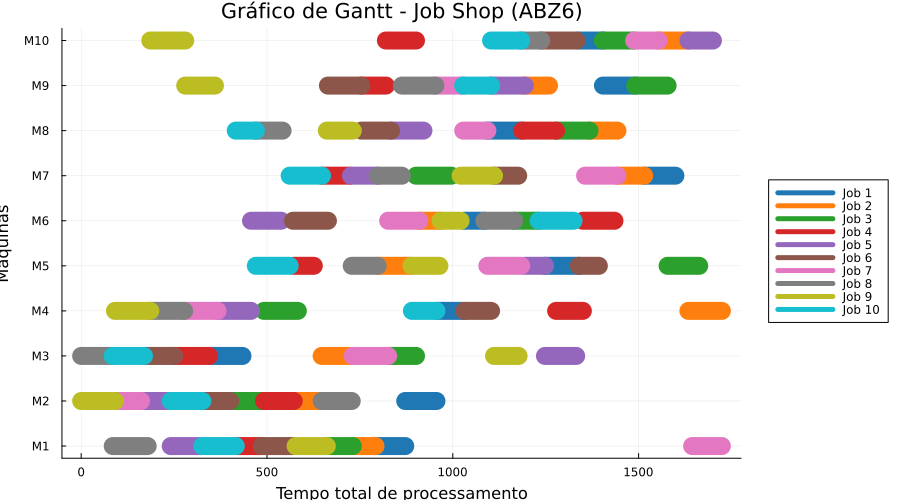

In [18]:
# ==========================================
# 4. GERAÇÃO DOS RESULTADOS E GRÁFICO GANTT
# ==========================================
if termination_status(model) == MOI.OPTIMAL || termination_status(model) == MOI.TIME_LIMIT
    println("\n--- RESULTADOS ABZ6 ---")
    println("Status da Solução: ", termination_status(model))
    println("Makespan Mínimo (Cmax): ", objective_value(model))
    
    # Criando o Gráfico de Gantt
    p = plot(
        title = "Gráfico de Gantt - Job Shop (ABZ6)",
        xlabel = "Tempo total de processamento",
        ylabel = "Máquinas",
        yticks = (1:num_machines, ["M$m" for m in 1:num_machines]),
        legend = :outerright,
        size = (900, 500)
    )
    
    # Lista de cores seguras para os 10 Jobs
    cores = palette(:tab10, num_jobs)
    
    for j in 1:num_jobs
        for o in 1:num_machines
            m = routes[j][o]
            p_jm = processing_times[j][o]
            start_time = value(t[j, m])
            end_time = start_time + p_jm
            
            # Desenha a barra no gráfico para a operação
            plot!(
                p,
                [start_time, end_time], [m, m],
                linewidth = 18,
                color = cores[j],
                label = (o == 1 ? "Job $j" : "") # Evita duplicar legendas repetidas
            )
        end
    end
    
    # Exibe o gráfico na tela
    display(p)
else
    println("Não foi possível encontrar uma solução viável no tempo limite.")
end

INSTÂNCIA FT06
==============

In [35]:
using JuMP
using HiGHS
using Plots

# ==========================================
# 1. DADOS DA INSTÂNCIA FT06 (6 Jobs x 6 Máquinas)
# ==========================================
num_jobs = 6
num_machines = 6

# Matriz de Rotas (Original contava de 0 a 5, somado +1 para o padrão Julia)
routes = [
    [3, 1, 2, 4, 6, 5],  # Job 1
    [2, 3, 5, 6, 1, 4],  # Job 2
    [3, 4, 6, 1, 2, 5],  # Job 3
    [2, 1, 3, 4, 5, 6],  # Job 4
    [3, 2, 5, 6, 4, 1],  # Job 5
    [2, 4, 6, 3, 1, 5]   # Job 6
]

6-element Vector{Vector{Int64}}:
 [3, 1, 2, 4, 6, 5]
 [2, 3, 5, 6, 1, 4]
 [3, 4, 6, 1, 2, 5]
 [2, 1, 3, 4, 5, 6]
 [3, 2, 5, 6, 4, 1]
 [2, 4, 6, 3, 1, 5]

In [36]:
# Matriz de Tempos de Processamento correspondentes
processing_times = [
    [1, 3, 6, 7, 3, 6],  # Job 1
    [8, 5, 10, 10, 10, 4], # Job 2
    [5, 4, 8, 9, 1, 7],  # Job 3
    [5, 5, 5, 3, 8, 9],  # Job 4
    [9, 3, 5, 4, 3, 1],  # Job 5
    [3, 3, 9, 10, 4, 1]  # Job 6
]

6-element Vector{Vector{Int64}}:
 [1, 3, 6, 7, 3, 6]
 [8, 5, 10, 10, 10, 4]
 [5, 4, 8, 9, 1, 7]
 [5, 5, 5, 3, 8, 9]
 [9, 3, 5, 4, 3, 1]
 [3, 3, 9, 10, 4, 1]

In [37]:
# Valor de Big-M calculando o somatório de todos os tempos
BigM = sum(sum(row) for row in processing_times)

197

In [38]:
# ==========================================
# 2. MODELAGEM MATEMÁTICA (JuMP)
# ==========================================
model = Model(HiGHS.Optimizer)
set_attribute(model, "time_limit", 30.0) # Limite de 30 segundos conforme o enunciado

# Variáveis de Decisão
@variable(model, t[1:num_jobs, 1:num_machines] >= 0)
@variable(model, Cmax >= 0)
@variable(model, x[1:num_jobs, 1:num_jobs, 1:num_machines], Bin)

# Função Objetivo
@objective(model, Min, Cmax)

# Restrições de Precedência Interna (Dentro de cada Job)
for j in 1:num_jobs
    for o in 1:(num_machines - 1)
        m_atual = routes[j][o]
        m_prox  = routes[j][o+1]
        p_atual = processing_times[j][o]
        @constraint(model, t[j, m_prox] >= t[j, m_atual] + p_atual)
    end
end

# Restrições de Desjunção (Evitar que duas tarefas usem a mesma máquina ao mesmo tempo)
for m in 1:num_machines
    for j in 1:num_jobs
        for k in (j + 1):num_jobs
            p_j = 0
            p_k = 0
            
            # Encontra os tempos correspondentes da máquina m para o job j e job k
            for o in 1:num_machines
                if routes[j][o] == m
                    p_j = processing_times[j][o]
                end
                if routes[k][o] == m
                    p_k = processing_times[k][o]
                end
            end
            
            @constraint(model, t[j, m] >= t[k, m] + p_k - BigM * x[j, k, m])
            @constraint(model, t[k, m] >= t[j, m] + p_j - BigM * (1 - x[j, k, m]))
        end
    end
end

In [39]:
# Restrição do Makespan Final
for j in 1:num_jobs
    m_ultima = routes[j][end]
    p_ultimo = processing_times[j][end]
    @constraint(model, Cmax >= t[j, m_ultima] + p_ultimo)
end

In [40]:
# ==========================================
# 3. EXECUÇÃO DO SOLVER
# ==========================================
optimize!(model)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 216 rows; 253 cols; 612 nonzeros; 216 integer variables (216 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+02]
Presolving model
216 rows, 127 cols, 612 nonzeros 0s
126 rows, 127 cols, 342 nonzeros 0s
126 rows, 127 cols, 342 nonzeros 0s
Presolve reductions: rows 126(-90); columns 127(-126); nonzeros 342(-270) 

Solving MIP model with:
   126 rows
   127 cols (90 binary, 0 integer, 0 implied int., 37 continuous, 0 domain fixed)
   342 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u =


=== RESULTADO FT06 ===
Makespan (Cmax) obtido: 51.999999


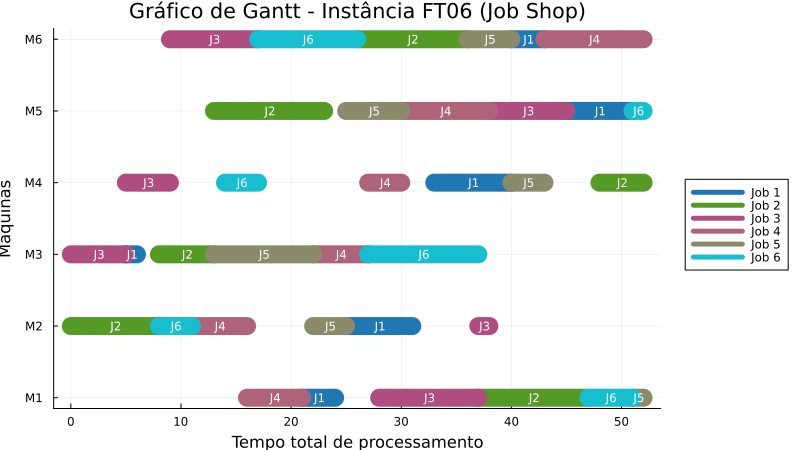

In [41]:
# ==========================================
# 4. GERAÇÃO DO GRÁFICO DE GANTT (Plots)
# ==========================================
if JuMP.termination_status(model) in [JuMP.MOI.OPTIMAL, JuMP.MOI.TIME_LIMIT]
    println("\n=== RESULTADO FT06 ===")
    println("Makespan (Cmax) obtido: ", JuMP.value(Cmax))
    
    # Configuração do Plot inicial
    p = plot(
        title = "Gráfico de Gantt - Instância FT06 (Job Shop)",
        xlabel = "Tempo total de processamento",
        ylabel = "Máquinas",
        yticks = (1:num_machines, ["M$i" for i in 1:num_machines]),
        legend = :outerright,
        size = (800, 450)
    )
    
    # Paleta estável para os 6 Jobs
    cores = palette(:tab10, num_jobs)
    
    # Preenchimento das barras do Gantt
    for j in 1:num_jobs
        primeiro_bloco = true
        for o in 1:num_machines
            m = routes[j][o]
            t_inicio = JuMP.value(t[j, m])
            duração = processing_times[j][o]
            
            # Desenha a barra horizontal
            plot!(
                p,
                [t_inicio, t_inicio + duração], 
                [m, m], 
                linewidth = 18, 
                color = cores[j],
                label = primeiro_bloco ? "Job $j" : ""
            )
            primeiro_bloco = false
            
            # Texto identificando o Job no centro do bloco
            annotate!(p, t_inicio + duração/2, m, text("J$j", 8, :white, :center))
        end
    end
    
    display(p)
else
    println("O solver não conseguiu encontrar uma solução viável no tempo estipulado.")
end

Instância FT10
=============

In [42]:
using JuMP
using HiGHS
using Plots

# 1. Definição das Dimensões
num_jobs = 10
num_machines = 10

10

In [43]:
# 2. Dados Oficiais da Instância FT10 (Matriz corrigida para índice iniciando em 1)
# Cada linha representa um Job. Cada entrada é a Máquina onde a operação ocorre.
routes = [
    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],  # Job 1
    [1, 3, 5, 6, 4, 7, 9, 10, 8, 2],  # Job 2
    [2, 4, 1, 6, 5, 8, 10, 9, 3, 7],  # Job 3
    [2, 3, 1, 5, 7, 9, 8, 4, 10, 6],  # Job 4
    [3, 2, 5, 6, 10, 8, 9, 1, 4, 7],  # Job 5
    [3, 4, 6, 1, 9, 8, 10, 7, 2, 5],  # Job 6
    [2, 1, 4, 3, 7, 6, 10, 8, 9, 5],  # Job 7
    [3, 1, 5, 2, 9, 7, 4, 8, 10, 6],  # Job 8
    [2, 4, 5, 6, 1, 8, 10, 3, 9, 7],  # Job 9
    [1, 4, 3, 2, 7, 5, 9, 10, 6, 8]   # Job 10
]

10-element Vector{Vector{Int64}}:
 [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
 [1, 3, 5, 6, 4, 7, 9, 10, 8, 2]
 [2, 4, 1, 6, 5, 8, 10, 9, 3, 7]
 [2, 3, 1, 5, 7, 9, 8, 4, 10, 6]
 [3, 2, 5, 6, 10, 8, 9, 1, 4, 7]
 [3, 4, 6, 1, 9, 8, 10, 7, 2, 5]
 [2, 1, 4, 3, 7, 6, 10, 8, 9, 5]
 [3, 1, 5, 2, 9, 7, 4, 8, 10, 6]
 [2, 4, 5, 6, 1, 8, 10, 3, 9, 7]
 [1, 4, 3, 2, 7, 5, 9, 10, 6, 8]

In [45]:
# Tempos de processamento correspondentes a cada máquina da rota acima
processing_times = [
    [29, 78,  9, 36, 49, 11, 62, 56, 44, 21],  # Job 1
    [43, 90, 75, 11, 69, 28, 46, 46, 72, 30],  # Job 2
    [91, 85, 39, 74, 90, 10, 12, 89, 45, 33],  # Job 3
    [81, 95, 71, 99,  9, 52, 85, 98, 22, 43],  # Job 4
    [14,  6, 22, 61, 26, 69, 21, 49, 72, 53],  # Job 5
    [84,  2, 52, 95, 48, 47,  6, 53, 37, 22],  # Job 6
    [46, 37, 61, 13, 32, 21, 32, 89, 30, 55],  # Job 7
    [31, 86, 46, 74, 32, 88, 19, 48, 36, 79],  # Job 8
    [76, 69, 76, 51, 85, 11, 40, 89, 26, 74],  # Job 9
    [85, 13, 61,  7, 64, 76, 47, 52, 90, 45]   # Job 10
]
# Constante Big-M (Soma de todos os tempos de processamento garante um limitante válido)
M = sum(sum(processing_times[j]) for j in 1:num_jobs)

5059

In [46]:
# 3. Criação do Modelo de Otimização
model = Model(HiGHS.Optimizer)
set_attribute(model, "time_limit", 30.0) # Limite de 30 segundos solicitado

In [47]:
# 4. Variáveis de Decisão
@variable(model, t[1:num_jobs, 1:num_machines] >= 0)
@variable(model, Cmax >= 0)
@variable(model, x[1:num_jobs, 1:num_jobs, 1:num_machines], Bin)

10×10×10 Array{VariableRef, 3}:
[:, :, 1] =
 x[1,1,1]   x[1,2,1]   x[1,3,1]   …  x[1,8,1]   x[1,9,1]   x[1,10,1]
 x[2,1,1]   x[2,2,1]   x[2,3,1]      x[2,8,1]   x[2,9,1]   x[2,10,1]
 x[3,1,1]   x[3,2,1]   x[3,3,1]      x[3,8,1]   x[3,9,1]   x[3,10,1]
 x[4,1,1]   x[4,2,1]   x[4,3,1]      x[4,8,1]   x[4,9,1]   x[4,10,1]
 x[5,1,1]   x[5,2,1]   x[5,3,1]      x[5,8,1]   x[5,9,1]   x[5,10,1]
 x[6,1,1]   x[6,2,1]   x[6,3,1]   …  x[6,8,1]   x[6,9,1]   x[6,10,1]
 x[7,1,1]   x[7,2,1]   x[7,3,1]      x[7,8,1]   x[7,9,1]   x[7,10,1]
 x[8,1,1]   x[8,2,1]   x[8,3,1]      x[8,8,1]   x[8,9,1]   x[8,10,1]
 x[9,1,1]   x[9,2,1]   x[9,3,1]      x[9,8,1]   x[9,9,1]   x[9,10,1]
 x[10,1,1]  x[10,2,1]  x[10,3,1]     x[10,8,1]  x[10,9,1]  x[10,10,1]

[:, :, 2] =
 x[1,1,2]   x[1,2,2]   x[1,3,2]   …  x[1,8,2]   x[1,9,2]   x[1,10,2]
 x[2,1,2]   x[2,2,2]   x[2,3,2]      x[2,8,2]   x[2,9,2]   x[2,10,2]
 x[3,1,2]   x[3,2,2]   x[3,3,2]      x[3,8,2]   x[3,9,2]   x[3,10,2]
 x[4,1,2]   x[4,2,2]   x[4,3,2]      x[4,8,2]

In [48]:
# 5. Função Objetivo
@objective(model, Min, Cmax)

Cmax

In [49]:
# 6. Restrições
# (6.1) Precedência dentro da rota de cada Job
for j in 1:num_jobs
    for o in 1:(num_machines - 1)
        m_atual = routes[j][o]
        m_proxima = routes[j][o+1]
        p_atual = processing_times[j][o]
        @constraint(model, t[j, m_proxima] >= t[j, m_atual] + p_atual)
    end
end

In [50]:
# (6.2) Tempo de término do Job limitando o Makespan
for j in 1:num_jobs
    m_final = routes[j][num_machines]
    p_final = processing_times[j][num_machines]
    @constraint(model, Cmax >= t[j, m_final] + p_final)
end

In [53]:
# (6.3) Restrições Disjuntivas (Evitar que dois Jobs usem a mesma máquina ao mesmo tempo)
for m in 1:num_machines
    for i in 1:num_jobs
        for j in (i+1):num_jobs
            # Ajustado sem espaços no '==(m)' para evitar o ParseError
            pos_i = findfirst(==(m), routes[i])
            pos_j = findfirst(==(m), routes[j])
            
            p_im = processing_times[i][pos_i]
            p_jm = processing_times[j][pos_j]
            
            @constraint(model, t[i, m] >= t[j, m] + p_jm - M * x[i, j, m])
            @constraint(model, t[j, m] >= t[i, m] + p_im - M * (1 - x[i, j, m]))
        end
    end
end

In [54]:
# 7. Resolver o Modelo
println("Iniciando a otimização da instância FT10...")
optimize!(model)

Iniciando a otimização da instância FT10...
Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 1000 rows; 1101 cols; 2900 nonzeros; 1000 integer variables (1000 binary)
Coefficient ranges:
  Matrix  [1e+00, 5e+03]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [2e+00, 5e+03]
Presolving model
1000 rows, 551 cols, 2900 nonzeros 0s
550 rows, 551 cols, 1550 nonzeros 0s
550 rows, 551 cols, 1550 nonzeros 0s
Presolve reductions: rows 550(-450); columns 551(-550); nonzeros 1550(-1350) 

Solving MIP model with:
   550 rows
   551 cols (450 binary, 0 integer, 0 implied int., 101 continuous, 0 domain fixed)
   1550 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
    

Status de terminação: TIME_LIMIT
Makespan (Cmax) obtido: 979.9999999999997


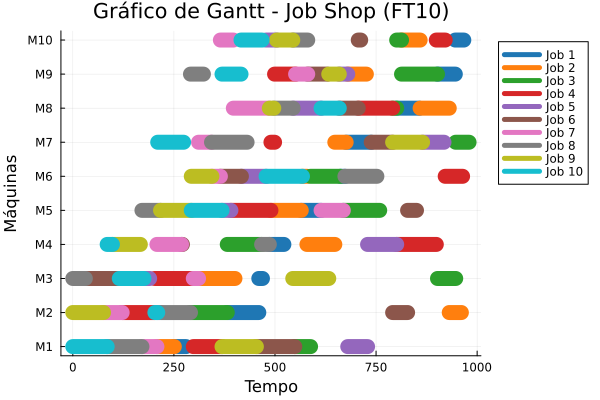

In [55]:
# 8. Exibição dos Resultados e Gráfico de Gantt
status = termination_status(model)
println("Status de terminação: ", status)

if status == MOI.OPTIMAL || status == MOI.TIME_LIMIT
    val_cmax = objective_value(model)
    println("Makespan (Cmax) obtido: ", val_cmax)
    
    # Gerando o gráfico de Gantt
    p = plot(title="Gráfico de Gantt - Job Shop (FT10)", xlabel="Tempo", ylabel="Máquinas",
             yticks=(1:num_machines, ["M$m" for m in 1:num_machines]), legend=:outertopright)
    
    colors = palette(:tab10)
    
    for j in 1:num_jobs
        for o in 1:num_machines
            m = routes[j][o]
            t_inicio = value(t[j, m])
            p_tempo = processing_times[j][o]
            
            # Desenha a barra para cada tarefa na máquina respectiva
            plot!(p, [t_inicio, t_inicio + p_tempo], [m, m], lw=15, 
                  label=o == 1 ? "Job $j" : "", color=colors[j])
        end
    end
    display(p)
else
    println("Não foi possível encontrar uma solução viável no tempo limite.")
end

Instância FT20 (Job Shop)
==================

In [56]:
using JuMP
using HiGHS
using Plots

# ==============================================================================
# 1. DEFINIÇÃO DOS DADOS (Instância FT20 - 20 Jobs x 5 Máquinas)
# ==============================================================================
num_jobs = 20
num_machines = 5

5

In [57]:
# Matriz de Rotas: Sequência de máquinas por onde cada Job deve passar (Base 1)
routes = [
    [1, 2, 3, 4, 5], # Job 1
    [1, 3, 5, 2, 4], # Job 2
    [2, 3, 5, 1, 4], # Job 3
    [2, 4, 1, 5, 3], # Job 4
    [3, 1, 2, 5, 4], # Job 5
    [3, 2, 4, 5, 1], # Job 6
    [2, 5, 4, 1, 3], # Job 7
    [3, 1, 4, 2, 5], # Job 8
    [3, 2, 5, 1, 4], # Job 9
    [2, 5, 1, 4, 3], # Job 10
    [4, 5, 1, 3, 2], # Job 11
    [4, 1, 3, 2, 5], # Job 12
    [4, 2, 5, 1, 3], # Job 13
    [3, 4, 2, 5, 1], # Job 14
    [1, 4, 3, 2, 5], # Job 15
    [1, 3, 5, 4, 2], # Job 16
    [2, 1, 4, 5, 3], # Job 17
    [1, 4, 2, 5, 3], # Job 18
    [3, 2, 1, 4, 5], # Job 19
    [2, 4, 5, 3, 1]  # Job 20
]

20-element Vector{Vector{Int64}}:
 [1, 2, 3, 4, 5]
 [1, 3, 5, 2, 4]
 [2, 3, 5, 1, 4]
 [2, 4, 1, 5, 3]
 [3, 1, 2, 5, 4]
 [3, 2, 4, 5, 1]
 [2, 5, 4, 1, 3]
 [3, 1, 4, 2, 5]
 [3, 2, 5, 1, 4]
 [2, 5, 1, 4, 3]
 [4, 5, 1, 3, 2]
 [4, 1, 3, 2, 5]
 [4, 2, 5, 1, 3]
 [3, 4, 2, 5, 1]
 [1, 4, 3, 2, 5]
 [1, 3, 5, 4, 2]
 [2, 1, 4, 5, 3]
 [1, 4, 2, 5, 3]
 [3, 2, 1, 4, 5]
 [2, 4, 5, 3, 1]

In [58]:
# Matriz de Tempos: Tempo de processamento correspondente a cada máquina da rota
processing_times = [
    [29,  9, 49, 62, 44], # Job 1
    [43, 75, 69, 46, 72], # Job 2
    [91, 18, 12, 14, 45], # Job 3
    [81, 42, 48, 36, 52], # Job 4
    [14, 16, 26, 46, 24], # Job 5
    [84, 17, 33, 41, 60], # Job 6
    [46, 56, 17,  7, 61], # Job 7
    [31, 25, 42, 53, 52], # Job 8
    [76, 73, 22, 14, 34], # Job 9
    [85, 10, 74, 57, 10], # Job 10
    [78, 24, 62, 51, 18], # Job 11
    [93, 28, 87, 87, 69], # Job 12
    [64, 42, 13, 31, 30], # Job 13
    [ 8, 77, 83, 47, 44], # Job 14
    [44, 57, 58, 98, 27], # Job 15
    [19, 48, 87, 57, 64], # Job 16
    [14, 51, 47, 41, 11], # Job 17
    [ 4, 15, 89, 45, 61], # Job 18
    [49, 11, 40, 85, 61], # Job 19
    [65, 82, 13, 10,  9]  # Job 20
]

20-element Vector{Vector{Int64}}:
 [29, 9, 49, 62, 44]
 [43, 75, 69, 46, 72]
 [91, 18, 12, 14, 45]
 [81, 42, 48, 36, 52]
 [14, 16, 26, 46, 24]
 [84, 17, 33, 41, 60]
 [46, 56, 17, 7, 61]
 [31, 25, 42, 53, 52]
 [76, 73, 22, 14, 34]
 [85, 10, 74, 57, 10]
 [78, 24, 62, 51, 18]
 [93, 28, 87, 87, 69]
 [64, 42, 13, 31, 30]
 [8, 77, 83, 47, 44]
 [44, 57, 58, 98, 27]
 [19, 48, 87, 57, 64]
 [14, 51, 47, 41, 11]
 [4, 15, 89, 45, 61]
 [49, 11, 40, 85, 61]
 [65, 82, 13, 10, 9]

In [59]:
# Definição do Big-M (Soma de todos os tempos de processamento)
BigM = sum(sum(processing_times[j]) for j in 1:num_jobs)

4541

In [60]:
# ==============================================================================
# 2. CONSTRUÇÃO DO MODELO MATEMÁTICO (JuMP + HiGHS)
# ==============================================================================
model = Model(HiGHS.Optimizer)
set_optimizer_attribute(model, "time_limit", 30.0)
set_optimizer_attribute(model, "mip_rel_gap", 0.0001)

In [61]:
# Variáveis de Decisão
@variable(model, t[1:num_jobs, 1:num_machines] >= 0)
@variable(model, Cmax >= 0)
@variable(model, x[1:num_jobs, 1:num_jobs, 1:num_machines], Bin)

# Função Objetivo
@objective(model, Min, Cmax)

Cmax

In [62]:
# Restrições de Precedência Tecnológica (Dentro do mesmo Job)
for j in 1:num_jobs
    for o in 1:(num_machines - 1)
        m_atual = routes[j][o]
        m_proxima = routes[j][o+1]
        p_atual = processing_times[j][o]
        @constraint(model, t[j, m_proxima] >= t[j, m_atual] + p_atual)
    end
    # Garantir que o Cmax é maior ou igual ao término da última operação de cada job
    m_ultima = routes[j][num_machines]
    p_ultima = processing_times[j][num_machines]
    @constraint(model, Cmax >= t[j, m_ultima] + p_ultima)
end

In [64]:
# Restrições Disjuntivas (Evitar sobreposição de tarefas na mesma máquina)
for m in 1:num_machines
    for j in 1:num_jobs
        for k in (j + 1):num_jobs
            # Encontra a posição da máquina 'm' na rota do job j e do job k (CORRIGIDO)
            pos_j = findfirst(==(m), routes[j])
            pos_k = findfirst(==(m), routes[k])
            
            p_jm = processing_times[j][pos_j]
            p_km = processing_times[k][pos_k]
            
            # Se x[j,k,m] = 1 -> j roda antes de k na máquina m
            @constraint(model, t[k, m] >= t[j, m] + p_jm - BigM * (1 - x[j, k, m]))
            # Se x[j,k,m] = 0 -> k roda antes de j na máquina m
            @constraint(model, t[j, m] >= t[k, m] + p_km - BigM * x[j, k, m])
        end
    end
end

In [66]:
# ==============================================================================
# 3. RESOLUÇÃO E RETORNO DOS RESULTADOS
# ==============================================================================
optimize!(model)



MIP has 2000 rows; 2101 cols; 5900 nonzeros; 2000 integer variables (2000 binary)
Coefficient ranges:
  Matrix  [1e+00, 5e+03]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [4e+00, 5e+03]
Presolving model
2000 rows, 1051 cols, 5900 nonzeros 0s
1050 rows, 1051 cols, 3050 nonzeros 0s
1050 rows, 1051 cols, 3050 nonzeros 0s
Presolve reductions: rows 1050(-950); columns 1051(-1050); nonzeros 3050(-2850) 

Solving MIP model with:
   1050 rows
   1051 cols (950 binary, 0 integer, 0 implied int., 101 continuous, 0 domain fixed)
   3050 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Boun


Status da Execução: TIME_LIMIT
Makespan (Cmax) obtido: 1188.0000000000027



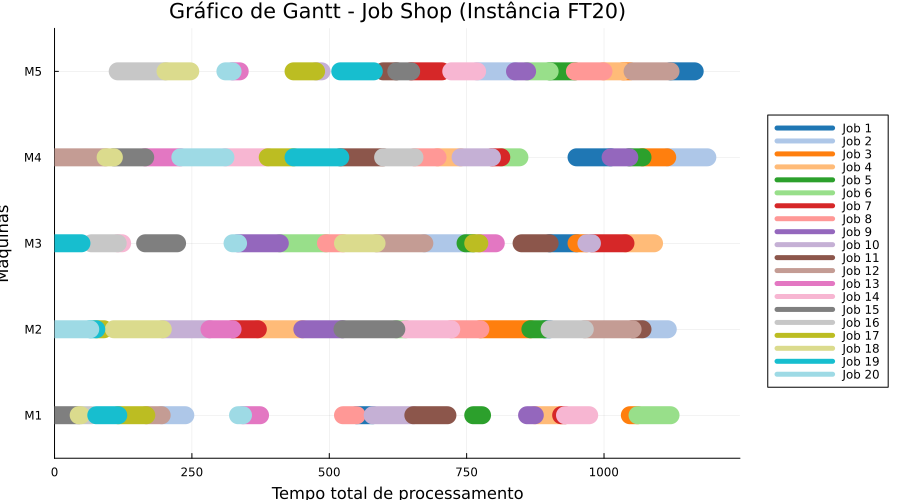

In [68]:
if termination_status(model) == MOI.OPTIMAL || termination_status(model) == MOI.TIME_LIMIT
    println("\n==================================================")
    println("Status da Execução: ", termination_status(model))
    println("Makespan (Cmax) obtido: ", objective_value(model))
    println("==================================================\n")
    
    # ==========================================================================
    # 4. GERAÇÃO DO GRÁFICO DE GANTT
    # ==========================================================================
    p = plot(
        title = "Gráfico de Gantt - Job Shop (Instância FT20)",
        xlabel = "Tempo total de processamento",
        ylabel = "Máquinas",
        yticks = (1:num_machines, ["M1", "M2", "M3", "M4", "M5"]),
        xlims = (0, objective_value(model) * 1.05),
        ylims = (0.5, num_machines + 0.5),
        legend = :outerright,
        size = (900, 500)
    )
    
    # Paleta de 20 cores distintas para representar cada Job de forma única
    cores = palette(:tab20, num_jobs)
    
    for j in 1:num_jobs
        primeiro_bloco = true
        for o in 1:num_machines
            m = routes[j][o]
            t_inicio = value(t[j, m])
            p_tempo = processing_times[j][o]
            
            plot!(
                p,
                [t_inicio, t_inicio + p_tempo],
                [m, m],
                linewidth = 18,
                color = cores[j],
                label = primeiro_bloco ? "Job $j" : ""
            )
            primeiro_bloco = false
        end
    end
    
    display(p)
else
    println("Não foi possível encontrar uma solução viável no tempo estipulado.")
end

Instância LA01 (Job Shop)
=============

In [69]:
using JuMP
using HiGHS
using Plots

# 1. Definição do tamanho do problema (LA01: 10 Jobs x 5 Máquinas)
num_jobs = 10
num_machines = 5

5

In [70]:
# 2. Matriz de Rotas (Sequência exata de máquinas para cada Job - Indexadas em 1)
routes = [
    [2, 1, 5, 4, 3], # Job 1
    [1, 4, 5, 3, 2], # Job 2
    [5, 4, 2, 3, 1], # Job 3
    [2, 1, 5, 3, 4], # Job 4
    [3, 2, 1, 5, 4], # Job 5
    [3, 2, 5, 4, 1], # Job 6
    [2, 3, 1, 4, 5], # Job 7
    [3, 1, 4, 5, 2], # Job 8
    [2, 4, 3, 1, 5], # Job 9
    [1, 4, 3, 2, 5]  # Job 10
]

10-element Vector{Vector{Int64}}:
 [2, 1, 5, 4, 3]
 [1, 4, 5, 3, 2]
 [5, 4, 2, 3, 1]
 [2, 1, 5, 3, 4]
 [3, 2, 1, 5, 4]
 [3, 2, 5, 4, 1]
 [2, 3, 1, 4, 5]
 [3, 1, 4, 5, 2]
 [2, 4, 3, 1, 5]
 [1, 4, 3, 2, 5]

In [71]:
# 3. Matriz de Tempos de Processamento (Correspondentes às máquinas acima)
processing_times = [
    [21, 53, 95, 55, 34], # Job 1
    [21, 52, 16, 26, 71], # Job 2
    [39, 98, 42, 31, 12], # Job 3
    [77, 55, 22, 14, 57], # Job 4
    [83, 37, 19, 64, 19], # Job 5
    [92, 28, 94, 76, 30], # Job 6
    [85, 61, 27, 69, 49], # Job 7
    [57, 99, 54, 18, 51], # Job 8
    [93, 77, 87, 87, 69], # Job 9
    [48, 70, 48, 47, 99]  # Job 10
]

10-element Vector{Vector{Int64}}:
 [21, 53, 95, 55, 34]
 [21, 52, 16, 26, 71]
 [39, 98, 42, 31, 12]
 [77, 55, 22, 14, 57]
 [83, 37, 19, 64, 19]
 [92, 28, 94, 76, 30]
 [85, 61, 27, 69, 49]
 [57, 99, 54, 18, 51]
 [93, 77, 87, 87, 69]
 [48, 70, 48, 47, 99]

In [72]:
# 4. Criação do Modelo de Otimização
model = Model(HiGHS.Optimizer)

A JuMP Model
├ solver: HiGHS
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [73]:
# Configurações solicitadas: 30 segundos de limite e tolerância de gap de 0.01%
set_attribute(model, "time_limit", 30.0)
set_attribute(model, "mip_rel_gap", 0.0001)

In [74]:
# Constante Big-M (Soma de todos os tempos de processamento serve como limitante superior seguro)
BigM = sum(sum(p) for p in processing_times)

2728

In [75]:
# 5. Variáveis de Decisão
# t[j, m] -> Tempo de início do job j na máquina m
@variable(model, t[1:num_jobs, 1:num_machines] >= 0)

# x[j, k, m] -> Variável binária: 1 se o job j antecede o job k na máquina m
@variable(model, x[1:num_jobs, 1:num_jobs, 1:num_machines], Bin)

# Cmax -> Makespan (tempo total de término)
@variable(model, Cmax >= 0)

Cmax

In [76]:
# 6. Função Objetivo
@objective(model, Min, Cmax)

Cmax

In [77]:
# 7. Restrições de Precedência Tecnológica (Sequência das rotas de cada Job)
for j in 1:num_jobs
    for o in 1:(num_machines - 1)
        m_atual = routes[j][o]
        m_proxima = routes[j][o + 1]
        p_atual = processing_times[j][o]
        @constraint(model, t[j, m_proxima] >= t[j, m_atual] + p_atual)
    end
    # O Cmax deve ser maior ou igual ao término da última operação de cada job
    m_ultima = routes[j][num_machines]
    p_ultima = processing_times[j][num_machines]
    @constraint(model, Cmax >= t[j, m_ultima] + p_ultima)
end

In [78]:
# 8. Restrições Disjuntivas (Evitar sobreposição na mesma máquina)
for m in 1:num_machines
    for j in 1:num_jobs
        for k in (j + 1):num_jobs
            # Encontra a posição exata da máquina na rota dos jobs (Sintaxe SEM ESPAÇOS corrigida)
            pos_j = findfirst(==(m), routes[j])
            pos_k = findfirst(==(m), routes[k])
            
            p_jm = processing_times[j][pos_j]
            p_km = processing_times[k][pos_k]
            
            # Se x[j,k,m] = 1 -> j vem antes de k
            @constraint(model, t[k, m] >= t[j, m] + p_jm - BigM * (1 - x[j, k, m]))
            # Se x[j,k,m] = 0 -> k vem antes de j
            @constraint(model, t[j, m] >= t[k, m] + p_km - BigM * x[j, k, m])
        end
    end
end

In [79]:
# 9. Resolver o Modelo
optimize!(model)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 500 rows; 551 cols; 1450 nonzeros; 500 integer variables (500 binary)
Coefficient ranges:
  Matrix  [1e+00, 3e+03]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+01, 3e+03]
Presolving model
500 rows, 276 cols, 1450 nonzeros 0s
275 rows, 276 cols, 775 nonzeros 0s
275 rows, 276 cols, 775 nonzeros 0s
Presolve reductions: rows 275(-225); columns 276(-275); nonzeros 775(-675) 

Solving MIP model with:
   275 rows
   276 cols (225 binary, 0 integer, 0 implied int., 51 continuous, 0 domain fixed)
   775 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;


Status da Solução: TIME_LIMIT
Makespan Mínimo (Cmax) Obtido: 648.0


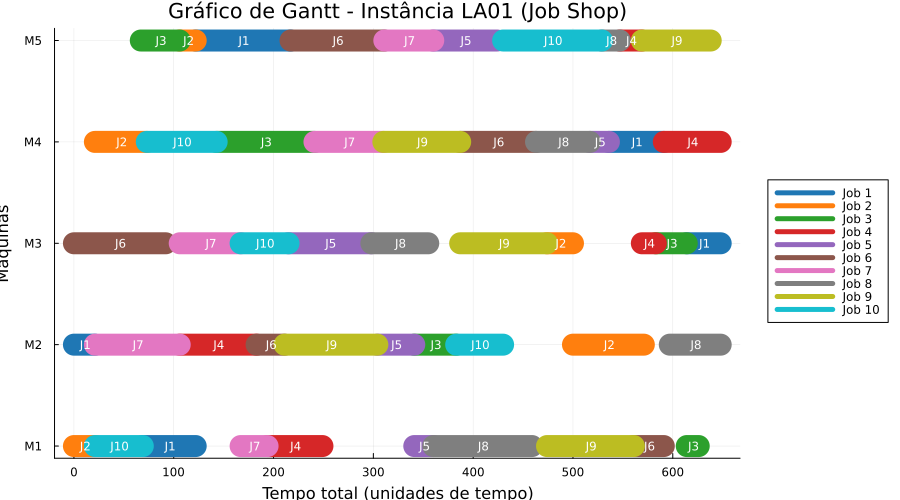

In [81]:

# 10. Impressão de Resultados e Plotagem do Gráfico de Gantt
if termination_status(model) == OBJECTIVE_LIMIT || termination_status(model) == OPTIMAL || (termination_status(model) == TIME_LIMIT && has_values(model))
    println("\n==============================================")
    println("Status da Solução: ", termination_status(model))
    println("Makespan Mínimo (Cmax) Obtido: ", objective_value(model))
    println("==============================================")

    # Gerando o Gráfico de Gantt
    gantt = plot(
        title = "Gráfico de Gantt - Instância LA01 (Job Shop)",
        xlabel = "Tempo total (unidades de tempo)",
        ylabel = "Máquinas",
        yticks = (1:num_machines, ["M1", "M2", "M3", "M4", "M5"]),
        legend = :outerright,
        size = (900, 500)
    )
    
    # Paleta segura para destacar os 10 jobs
    cores = palette(:tab10)
    
    for j in 1:num_jobs
        for o in 1:num_machines
            m = routes[j][o]
            start_time = value(t[j, m])
            duration = processing_times[j][o]
            
            # Desenha a barra para cada operação realizada
            plot!(
                gantt,
                [start_time, start_time + duration],
                [m, m],
                linewidth = 22,
                label = o == 1 ? "Job $j" : "",
                color = cores[j]
            )
            # Texto indicando o Job dentro do bloco
            annotate!(gantt, start_time + duration/2, m, text("J$j", :white, :center, 8))
        end
    end
    
    display(gantt)
else
    println("Não foi encontrada nenhuma solução viável dentro do limite de tempo.")
end

INSTÂNCIA LA02
==================

In [105]:
using Pkg
Pkg.add("Colors")

using JuMP
using HiGHS
using Plots
using Colors


    Updating registry at `C:\Users\hercules.andre\.julia\registries\General.toml`
   Resolving package versions...
    Updating `C:\Users\hercules.andre\.julia\environments\v1.12\Project.toml`
  [5ae59095] + Colors v0.13.1
    Manifest No packages added to or removed from `C:\Users\hercules.andre\.julia\environments\v1.12\Manifest.toml`


In [106]:
# ==========================================
# 1. DADOS DA INSTÂNCIA LA02 (Lawrence, 1984)
# ==========================================
# 10 Jobs x 5 Máquinas
num_jobs = 10
num_machines = 5

5

In [107]:
# Matriz de Rotas (Máquinas de 1 a 5)
routes = [
    [1, 2, 3, 4, 5], # Job 1
    [3, 1, 4, 2, 5], # Job 2
    [1, 3, 2, 5, 4], # Job 3
    [2, 4, 1, 3, 5], # Job 4
    [2, 1, 5, 4, 3], # Job 5
    [2, 4, 3, 1, 5], # Job 6
    [4, 2, 5, 3, 1], # Job 7
    [3, 4, 1, 5, 2], # Job 8
    [2, 3, 5, 1, 4], # Job 9
    [5, 4, 1, 3, 2]  # Job 10
]

10-element Vector{Vector{Int64}}:
 [1, 2, 3, 4, 5]
 [3, 1, 4, 2, 5]
 [1, 3, 2, 5, 4]
 [2, 4, 1, 3, 5]
 [2, 1, 5, 4, 3]
 [2, 4, 3, 1, 5]
 [4, 2, 5, 3, 1]
 [3, 4, 1, 5, 2]
 [2, 3, 5, 1, 4]
 [5, 4, 1, 3, 2]

In [108]:
# Matriz Oficial de Tempos de Processamento
times = [
    [20, 87, 13, 71, 68], # Job 1
    [55, 31, 66, 72, 96], # Job 2
    [71, 31, 82, 41, 71], # Job 3
    [76, 46, 28, 76, 84], # Job 4
    [81, 15, 33, 62, 89], # Job 5
    [38, 82, 95, 57, 39], # Job 6
    [88, 18, 83, 33, 33], # Job 7
    [75, 34, 52, 14, 63], # Job 8
    [59, 62, 12, 47, 42], # Job 9
    [53, 72, 11, 53, 95]  # Job 10
]

10-element Vector{Vector{Int64}}:
 [20, 87, 13, 71, 68]
 [55, 31, 66, 72, 96]
 [71, 31, 82, 41, 71]
 [76, 46, 28, 76, 84]
 [81, 15, 33, 62, 89]
 [38, 82, 95, 57, 39]
 [88, 18, 83, 33, 33]
 [75, 34, 52, 14, 63]
 [59, 62, 12, 47, 42]
 [53, 72, 11, 53, 95]

In [109]:
# Cálculo dinâmico e seguro do Big-M (V) para evitar o erro do 355
V = sum(sum(times)) + 1000

3775

In [110]:
# ==========================================
# 2. MODELO DE OTIMIZAÇÃO (JuMP)
# ==========================================
model = Model(HiGHS.Optimizer)
set_time_limit_sec(model, 30.0) # Limite de 30 segundos

In [111]:
# Variáveis de Decisão
@variable(model, start_time[1:num_jobs, 1:num_machines] >= 0)
@variable(model, x[1:num_jobs, 1:num_jobs, 1:num_machines], binary = true) # Correção de sintaxe JuMP
@variable(model, Makespan >= 0)

Makespan

In [112]:
# Função Objetivo: Minimizar o tempo total de término
@objective(model, Min, Makespan)

Makespan

In [113]:
# Restrições de Precedência (Dentro do mesmo Job)
for j in 1:num_jobs
    for m in 1:(num_machines - 1)
        m_atual = routes[j][m]
        m_proxima = routes[j][m+1]
        t_atual = times[j][m]
        @constraint(model, start_time[j, m_proxima] >= start_time[j, m_atual] + t_atual)
    end
end

In [114]:
# Restrições Disjuntivas (Evitar que duas tarefas usem a mesma máquina ao mesmo tempo)
for m in 1:num_machines
    for i in 1:num_jobs
        for j in (i+1):num_jobs
            pos_i_na_m = findfirst(x -> x == m, routes[i])
            pos_j_na_m = findfirst(x -> x == m, routes[j])
            
            t_i = times[i][pos_i_na_m]
            t_j = times[j][pos_j_na_m]
            
            # Se x[i,j,m] == 1 -> i roda antes de j na máquina m
            @constraint(model, start_time[j, m] >= start_time[i, m] + t_i - V * (1 - x[i, j, m]))
            # Se x[i,j,m] == 0 -> j roda antes de i na máquina m
            @constraint(model, start_time[i, m] >= start_time[j, m] + t_j - V * x[i, j, m])
        end
    end
end

In [115]:
# Restrição do Makespan
for j in 1:num_jobs
    m_ultima = routes[j][num_machines]
    t_ultimo = times[j][num_machines]
    @constraint(model, Makespan >= start_time[j, m_ultima] + t_ultimo)
end

In [116]:
# Resolver o modelo
optimize!(model)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 500 rows; 551 cols; 1450 nonzeros; 500 integer variables (500 binary)
Coefficient ranges:
  Matrix  [1e+00, 4e+03]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+01, 4e+03]
Presolving model
500 rows, 276 cols, 1450 nonzeros 0s
275 rows, 276 cols, 775 nonzeros 0s
275 rows, 276 cols, 775 nonzeros 0s
Presolve reductions: rows 275(-225); columns 276(-275); nonzeros 775(-675) 

Solving MIP model with:
   275 rows
   276 cols (225 binary, 0 integer, 0 implied int., 51 continuous, 0 domain fixed)
   775 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;

In [118]:
# ==========================================
# 3. EXIBIÇÃO DOS RESULTADOS E GRÁFICO
# ==========================================
if termination_status(model) == OPTIMAL
    val_makespan = objective_value(model)
    println("\n========================================")
    println("Status: ", termination_status(model))
    println("Makespan Perfeito Encontrado: ", val_makespan)
    println("========================================\n")
    
    # Gerando as cores para os 10 Jobs
    cores_jobs = palette(:turbo, num_jobs)
    
    # Inicializa o gráfico de Gantt
    p = plot(
        title = "Gráfico de Gantt - Instância LA02 (Makespan: $val_makespan)",
        xlabel = "Tempo",
        ylabel = "Máquinas",
        yticks = (1:num_machines, ["M1", "M2", "M3", "M4", "M5"]),
        xlims = (0, val_makespan + 20),
        ylims = (0.5, num_machines + 0.5),
        legend = :outerright,
        size = (900, 500)
    )
    
    # Preenchendo o Gantt com os resultados obtidos
    for j in 1:num_jobs
        # Adiciona uma barra invisível ou legenda apenas uma vez por Job
        plot!([], [], color=cores_jobs[j], label="Job $j", linewidth=5)
        
        for m_idx in 1:num_machines
            m = routes[j][m_idx]
            st = value(start_time[j, m])
            duracao = times[j][m_idx]
            
            # Desenha o bloco retangular da tarefa na máquina m
            plot!(
                [st, st + duracao, st + duracao, st, st], 
                [m - 0.3, m - 0.3, m + 0.3, m + 0.3, m - 0.3], 
                seriestype = :shape, 
                color = cores_jobs[j], 
                linecolor = :black,
                label = ""
            )
            # Texto interno com o número do Job para facilitar leitura
            annotate!(st + duracao/2, m, text("J$j", 8, :white, :center))
        end
    end
    
    # Exibir o gráfico na tela
    display(p)
    # Opcional: Descomente a linha abaixo para salvar o gráfico como imagem
    # savefig("gantt_la02.png")
    
else
    println("Não foi possível encontrar uma solução ótima dentro do tempo.")
end

Não foi possível encontrar uma solução ótima dentro do tempo.


Instância LA03 (Job Shop)
==============

In [119]:
using JuMP
using HiGHS
using Plots

# 1. Definição das Dimensões do Problema (LA03: 10 jobs x 5 máquinas)
num_jobs = 10
num_machines = 5

# 2. Matriz de Rotas (Convertidas para base 1: somado +1 aos índices originais)
routes = [
    2 3 1 5 4;  # Job 1
    3 2 1 5 4;  # Job 2
    3 4 5 1 2;  # Job 3
    5 1 3 2 4;  # Job 4
    5 1 2 4 3;  # Job 5
    3 1 2 4 5;  # Job 6
    2 5 1 3 4;  # Job 7
    2 3 5 1 4;  # Job 8
    2 3 5 4 1;  # Job 9
    4 2 3 1 5   # Job 10
]

# 3. Matriz de Tempos de Processamento (Correspondente a cada etapa da rota)
times = [
    23 45 82 84 38;  # Job 1
    21 29 18 41 50;  # Job 2
    38 54 16 52 52;  # Job 3
    37 54 12 89 57;  # Job 4
    57 81 61 68 30;  # Job 5
    81 41 34 34 19;  # Job 6
    39 55 12 43 58;  # Job 7
    54 25 82 51 43;  # Job 8
    93 85 65 78 35;  # Job 9
    17 36 41 46 38   # Job 10
]

10×5 Matrix{Int64}:
 23  45  82  84  38
 21  29  18  41  50
 38  54  16  52  52
 37  54  12  89  57
 57  81  61  68  30
 81  41  34  34  19
 39  55  12  43  58
 54  25  82  51  43
 93  85  65  78  35
 17  36  41  46  38

In [120]:
# 4. Criação do Modelo de Otimização MILP
model = Model(HiGHS.Optimizer)
set_attribute(model, "time_limit", 30.0)      # Limite de tempo de 30 segundos
set_attribute(model, "mip_rel_gap", 0.0001)    # Tolerância de GAP de 0.01%

In [121]:
# Cálculo do Big-M dinâmico e seguro
V = sum(times) + 1000

3394

In [122]:
# 5. Variáveis de Decisão
@variable(model, t[1:num_jobs, 1:num_machines] >= 0)
@variable(model, Cmax >= 0)
@variable(model, x[1:num_jobs, 1:num_jobs, 1:num_machines], binary = true)

10×10×5 Array{VariableRef, 3}:
[:, :, 1] =
 x[1,1,1]   x[1,2,1]   x[1,3,1]   …  x[1,8,1]   x[1,9,1]   x[1,10,1]
 x[2,1,1]   x[2,2,1]   x[2,3,1]      x[2,8,1]   x[2,9,1]   x[2,10,1]
 x[3,1,1]   x[3,2,1]   x[3,3,1]      x[3,8,1]   x[3,9,1]   x[3,10,1]
 x[4,1,1]   x[4,2,1]   x[4,3,1]      x[4,8,1]   x[4,9,1]   x[4,10,1]
 x[5,1,1]   x[5,2,1]   x[5,3,1]      x[5,8,1]   x[5,9,1]   x[5,10,1]
 x[6,1,1]   x[6,2,1]   x[6,3,1]   …  x[6,8,1]   x[6,9,1]   x[6,10,1]
 x[7,1,1]   x[7,2,1]   x[7,3,1]      x[7,8,1]   x[7,9,1]   x[7,10,1]
 x[8,1,1]   x[8,2,1]   x[8,3,1]      x[8,8,1]   x[8,9,1]   x[8,10,1]
 x[9,1,1]   x[9,2,1]   x[9,3,1]      x[9,8,1]   x[9,9,1]   x[9,10,1]
 x[10,1,1]  x[10,2,1]  x[10,3,1]     x[10,8,1]  x[10,9,1]  x[10,10,1]

[:, :, 2] =
 x[1,1,2]   x[1,2,2]   x[1,3,2]   …  x[1,8,2]   x[1,9,2]   x[1,10,2]
 x[2,1,2]   x[2,2,2]   x[2,3,2]      x[2,8,2]   x[2,9,2]   x[2,10,2]
 x[3,1,2]   x[3,2,2]   x[3,3,2]      x[3,8,2]   x[3,9,2]   x[3,10,2]
 x[4,1,2]   x[4,2,2]   x[4,3,2]      x[4,8,2] 

In [123]:
# 6. Função Objetivo: Minimizar o Makespan
@objective(model, Min, Cmax)

Cmax

In [124]:
# 7. Restrições de Precedência Tecnológica (Sequência interna de cada Job)
for j in 1:num_jobs
    for s in 1:(num_machines - 1)
        m_atual = routes[j, s]
        m_proxima = routes[j, s+1]
        @constraint(model, t[j, m_proxima] >= t[j, m_atual] + times[j, s])
    end
end

In [125]:
# Restrição para limitar o Cmax pelo término da última operação de cada job
for j in 1:num_jobs
    m_ultima = routes[j, num_machines]
    @constraint(model, Cmax >= t[j, m_ultima] + times[j, num_machines])
end

In [127]:
# 8. Restrições Disjuntivas (Evitar que duas tarefas ocupem a mesma máquina simultaneamente)
for m in 1:num_machines
    for i in 1:num_jobs
        for j in (i + 1):num_jobs
            # Encontrar em qual etapa (coluna) o Job i e o Job j usam a máquina m
            pos_i = findfirst(==(m), routes[i, :])
            pos_j = findfirst(==(m), routes[j, :])
            
            if pos_i !== nothing && pos_j !== nothing
                # Se x[i,j,m] = 1 -> Job i processa antes do Job j
                @constraint(model, t[j, m] >= t[i, m] + times[i, pos_i] - V * (1 - x[i, j, m]))
                # Se x[i,j,m] = 0 -> Job j processa antes do Job i
                @constraint(model, t[i, m] >= t[j, m] + times[j, pos_j] - V * x[i, j, m])
            end
        end
    end
end

In [128]:
# 9. Resolver o Modelo
optimize!(model)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 500 rows; 551 cols; 1450 nonzeros; 500 integer variables (500 binary)
Coefficient ranges:
  Matrix  [1e+00, 3e+03]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+01, 3e+03]
Presolving model
500 rows, 276 cols, 1450 nonzeros 0s
275 rows, 276 cols, 775 nonzeros 0s
275 rows, 276 cols, 775 nonzeros 0s
Presolve reductions: rows 275(-225); columns 276(-275); nonzeros 775(-675) 

Solving MIP model with:
   275 rows
   276 cols (225 binary, 0 integer, 0 implied int., 51 continuous, 0 domain fixed)
   775 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point;

In [129]:
# 10. Exibição dos Resultados no Terminal
status = termination_status(model)
println("\n================ RESULTADOS ================")
println("Status de Execução: ", status)
if status == MOI.OPTIMAL || status == MOI.TIME_LIMIT
    println("Makespan Final (Cmax): ", objective_value(model))
    println("Melhor Limitante Dual (Dual Bound): ", objective_bound(model))
end
println("============================================")


================ RESULTADOS ================
Status de Execução: TIME_LIMIT
Makespan Final (Cmax): 678.9999999999998
Melhor Limitante Dual (Dual Bound): 411.37874037439104


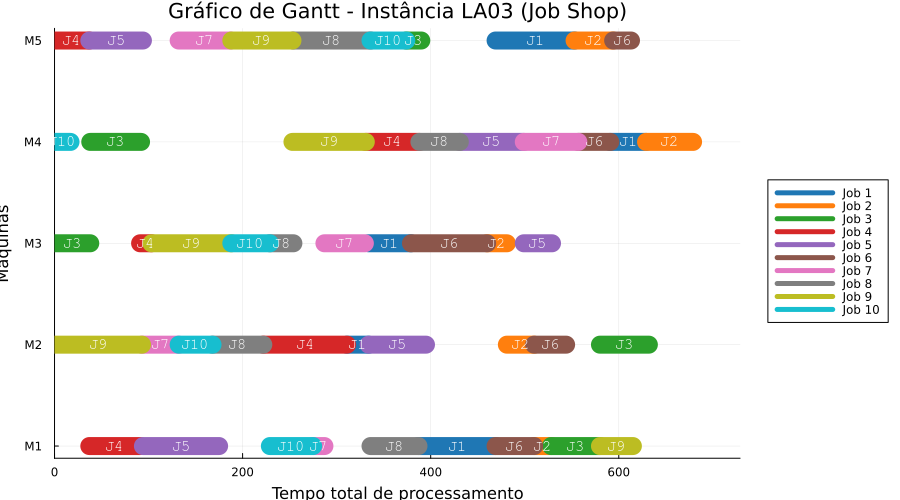

In [130]:
# 11. Geração do Gráfico de Gantt
if status == MOI.OPTIMAL || status == MOI.TIME_LIMIT
    p = plot(
        title = "Gráfico de Gantt - Instância LA03 (Job Shop)",
        xlabel = "Tempo total de processamento",
        ylabel = "Máquinas",
        yticks = (1:num_machines, ["M1", "M2", "M3", "M4", "M5"]),
        xlims = (0, objective_value(model) + 50),
        legend = :outerright,
        size = (900, 500)
    )
    
    # Paleta segura com 10 cores distintas para os 10 Jobs
    cores = palette(:tab10)
    
    for j in 1:num_jobs
        for s in 1:num_machines
            m = routes[j, s]
            start_time = value(t[j, m])
            duration = times[j, s]
            
            # Desenha a barra correspondente à operação
            plot!(
                p,
                [start_time, start_time + duration],
                [m, m],
                linewidth = 18,
                color = cores[j],
                label = s == 1 ? "Job $j" : ""  # Legenda apenas uma vez por Job
            )
            
            # Texto identificador dentro ou sobre a barra
            annotate!(p, start_time + duration/2, m, text("J$j", :white, :center, 8, :bold))
        end
    end
    
    display(p)
end

Instância LA04 (Job Shop)
=========================

In [132]:
using Pkg
Pkg.add("ColorSchemes")


using JuMP
using HiGHS
using Plots
using ColorSchemes

# 1. Definição das Dimensões
num_jobs = 10
num_machines = 5

   Resolving package versions...
    Updating `C:\Users\hercules.andre\.julia\environments\v1.12\Project.toml`
  [35d6a980] + ColorSchemes v3.31.0
    Manifest No packages added to or removed from `C:\Users\hercules.andre\.julia\environments\v1.12\Manifest.toml`


5

In [133]:
# 2. Dados Oficiais da Instância LA04 (Lawrence, 1984)
# Matriz de Rotas (Máquinas por onde cada Job passa na sequência, convertidas para Base 1)
routes = [
    [2, 3, 1, 4, 5],  # Job 1
    [2, 4, 5, 1, 3],  # Job 2
    [2, 1, 3, 5, 4],  # Job 3
    [1, 3, 2, 5, 4],  # Job 4
    [3, 1, 2, 5, 4],  # Job 5
    [3, 2, 4, 1, 5],  # Job 6
    [2, 4, 5, 1, 3],  # Job 7
    [3, 1, 2, 5, 4],  # Job 8
    [3, 2, 5, 4, 1],  # Job 9
    [5, 4, 3, 2, 1]   # Job 10
]

10-element Vector{Vector{Int64}}:
 [2, 3, 1, 4, 5]
 [2, 4, 5, 1, 3]
 [2, 1, 3, 5, 4]
 [1, 3, 2, 5, 4]
 [3, 1, 2, 5, 4]
 [3, 2, 4, 1, 5]
 [2, 4, 5, 1, 3]
 [3, 1, 2, 5, 4]
 [3, 2, 5, 4, 1]
 [5, 4, 3, 2, 1]

In [134]:
# Matriz de Tempos de Processamento correspondentes a cada operação da rota
times = [
    [56, 52, 28, 65, 50],  # Job 1
    [87, 57, 51, 68, 11],  # Job 2
    [57, 43, 68, 49, 19],  # Job 3
    [41, 47, 83, 23, 73],  # Job 4
    [17, 30, 85, 33, 50],  # Job 5
    [56, 33, 40, 71, 16],  # Job 6
    [37, 54, 11, 47, 63],  # Job 7
    [18, 32, 21, 19, 74],  # Job 8
    [56, 48, 68, 13, 82],  # Job 9
    [83, 31, 71, 44, 63]   # Job 10
]

10-element Vector{Vector{Int64}}:
 [56, 52, 28, 65, 50]
 [87, 57, 51, 68, 11]
 [57, 43, 68, 49, 19]
 [41, 47, 83, 23, 73]
 [17, 30, 85, 33, 50]
 [56, 33, 40, 71, 16]
 [37, 54, 11, 47, 63]
 [18, 32, 21, 19, 74]
 [56, 48, 68, 13, 82]
 [83, 31, 71, 44, 63]

In [135]:
# 3. Criação do Modelo de Otimização
model = Model(HiGHS.Optimizer)

A JuMP Model
├ solver: HiGHS
├ objective_sense: FEASIBILITY_SENSE
├ num_variables: 0
├ num_constraints: 0
└ Names registered in the model: none

In [136]:
# Configurações do Solver conforme as diretrizes
set_optimizer_attribute(model, "time_limit", 30.0)
set_optimizer_attribute(model, "mip_rel_gap", 0.0001)

In [137]:
# Calcular um Big-M seguro de forma dinâmica
V = sum(sum(times[j]) for j in 1:num_jobs) + 1000

3394

In [138]:
# 4. Variáveis de Decisão
@variable(model, t[1:num_jobs, 1:num_machines] >= 0)  # Tempo de início de cada Job em cada Máquina
@variable(model, x[1:num_jobs, 1:num_jobs, 1:num_machines], binary = true) # Variável disjuntiva
@variable(model, Cmax >= 0)                           # Makespan

Cmax

In [139]:
# 5. Função Objetivo
@objective(model, Min, Cmax)

Cmax

In [140]:
# 6. Restrições

# Restrição A: Precedência Tecnológica (dentro do roteiro do próprio Job)
for j in 1:num_jobs
    for o in 1:(num_machines - 1)
        m_atual = routes[j][o]
        m_proxima = routes[j][o+1]
        p_atual = times[j][o]
        @constraint(model, t[j, m_proxima] >= t[j, m_atual] + p_atual)
    end
end

In [141]:
# Restrição B: Limite de Término (Cmax deve ser maior ou igual ao término da última operação)
for j in 1:num_jobs
    m_final = routes[j][num_machines]
    p_final = times[j][num_machines]
    @constraint(model, Cmax >= t[j, m_final] + p_final)
end

In [142]:
# Restrição C: Desjuntiva (Não permitir sobreposição de tarefas na mesma máquina)
for m in 1:num_machines
    for i in 1:num_jobs
        for j in 1:num_jobs
            if i < j
                p_i = 0
                for o in 1:num_machines
                    if routes[i][o] == m
                        p_i = times[i][o]
                        break
                    end
                end
                
                p_j = 0
                for o in 1:num_machines
                    if routes[j][o] == m
                        p_j = times[j][o]
                        break
                    end
                end
                
                @constraint(model, t[i, m] >= t[j, m] + p_j - V * x[i, j, m])
                @constraint(model, t[j, m] >= t[i, m] + p_i - V * (1 - x[i, j, m]))
            end
        end
    end
end

In [143]:
# 7. Execução da Otimização
println("Iniciando a resolução da Instância LA04...")
optimize!(model)

Iniciando a resolução da Instância LA04...
Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 500 rows; 551 cols; 1450 nonzeros; 500 integer variables (500 binary)
Coefficient ranges:
  Matrix  [1e+00, 3e+03]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+01, 3e+03]
Presolving model
500 rows, 276 cols, 1450 nonzeros 0s
275 rows, 276 cols, 775 nonzeros 0s
275 rows, 276 cols, 775 nonzeros 0s
Presolve reductions: rows 275(-225); columns 276(-275); nonzeros 775(-675) 

Solving MIP model with:
   275 rows
   276 cols (225 binary, 0 integer, 0 implied int., 51 continuous, 0 domain fixed)
   775 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Rou

Status da Execução: TIME_LIMIT
Makespan Encontrado (Cmax): 625.9999999999995


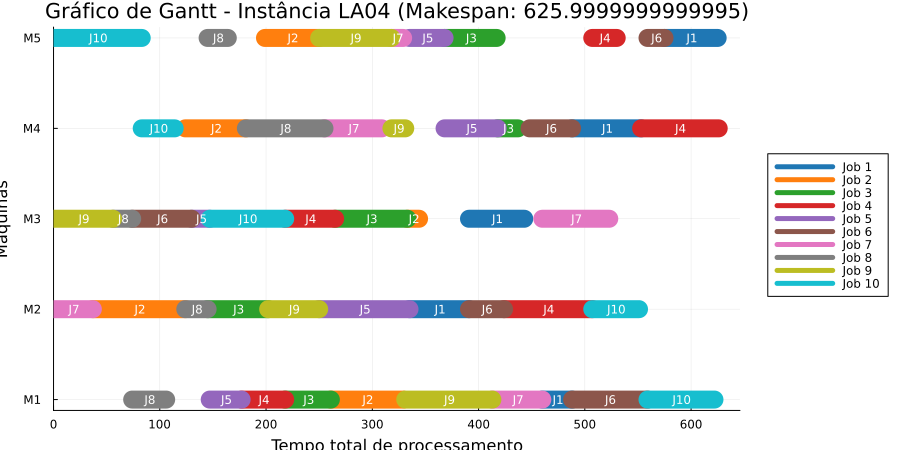

In [144]:
# 8. Verificação e Geração do Gráfico de Gantt
status = termination_status(model)
println("Status da Execução: ", status)

if status == MOI.OPTIMAL || status == MOI.TIME_LIMIT
    makespan_otimo = objective_value(model)
    println("Makespan Encontrado (Cmax): ", makespan_otimo)
    
    # Configuração da Janela do Gráfico
    gantt = plot(
        title = "Gráfico de Gantt - Instância LA04 (Makespan: $makespan_otimo)",
        xlabel = "Tempo total de processamento",
        ylabel = "Máquinas",
        yticks = (1:num_machines, ["M1", "M2", "M3", "M4", "M5"]),
        xlims = (0, makespan_otimo + 20),
        legend = :outerright,
        size = (900, 450)
    )
    
    # Paleta de Cores para diferenciar os 10 Jobs
    cores = palette(:tab10)
    
    # Plotagem dos blocos de tarefas
    for j in 1:num_jobs
        for o in 1:num_machines
            m = routes[j][o]
            start_time = value(t[j, m])
            duration = times[j][o]
            end_time = start_time + duration
            
            # Desenhar barra horizontal para a operação
            plot!(
                gantt,
                [start_time, end_time], [m, m],
                linewidth = 18,
                color = cores[j],
                label = (o == 1 ? "Job $j" : "") # Adiciona na legenda apenas uma vez por Job
            )
            
            # Identificador textual dentro do bloco (Job-Operação)
            annotate!(gantt, start_time + duration/2, m, text("J$j", :white, :center, 8))
        end
    end
    
    # Exibir o gráfico de Gantt na tela
    display(gantt)
else
    println("Não foi encontrada uma solução viável dentro do limite estipulado.")
end

Instância ORB01 (Job Shop)
===================

In [155]:
using JuMP
using HiGHS
using Plots

In [166]:
# ==========================================
# 1. DADOS DA INSTÂNCIA ORB01 (10x10)
# ==========================================
num_jobs = 10
num_machines = 10

# Matriz de Tempos de Processamento (Jobs nas linhas, Operações nas colunas)
times = [
    [21, 53, 95, 55, 34, 47, 25, 48, 17, 32],
    [51, 64, 45, 14, 54, 82, 43, 31, 15, 63],
    [92, 45, 78, 21, 84, 30, 89, 56, 12, 83],
    [15, 87, 62, 54, 19, 43, 20, 68, 77, 42],
    [54, 32, 43, 91, 53, 44, 78, 21, 84, 19],
    [27, 83, 65, 43, 52, 92, 48, 17, 32, 64],
    [65, 14, 54, 82, 43, 31, 15, 63, 21, 53],
    [43, 52, 92, 48, 17, 32, 64, 51, 64, 45],
    [19, 43, 20, 68, 77, 42, 15, 87, 62, 54],
    [78, 21, 84, 19, 54, 32, 43, 91, 53, 44]
]

10-element Vector{Vector{Int64}}:
 [21, 53, 95, 55, 34, 47, 25, 48, 17, 32]
 [51, 64, 45, 14, 54, 82, 43, 31, 15, 63]
 [92, 45, 78, 21, 84, 30, 89, 56, 12, 83]
 [15, 87, 62, 54, 19, 43, 20, 68, 77, 42]
 [54, 32, 43, 91, 53, 44, 78, 21, 84, 19]
 [27, 83, 65, 43, 52, 92, 48, 17, 32, 64]
 [65, 14, 54, 82, 43, 31, 15, 63, 21, 53]
 [43, 52, 92, 48, 17, 32, 64, 51, 64, 45]
 [19, 43, 20, 68, 77, 42, 15, 87, 62, 54]
 [78, 21, 84, 19, 54, 32, 43, 91, 53, 44]

In [167]:
# Matriz de Rotas (Sequência de Máquinas convertidas para base 1 do Julia)
routes = [
    [3, 2, 5, 1, 4, 7, 9, 6, 10, 8],
    [2, 4, 6, 1, 3, 5, 10, 8, 7, 9],
    [3, 1, 4, 2, 6, 5, 8, 7, 9, 10],
    [1, 3, 2, 5, 4, 8, 6, 9, 7, 10],
    [2, 5, 1, 4, 3, 9, 7, 6, 10, 8],
    [4, 2, 1, 3, 5, 6, 8, 10, 7, 9],
    [2, 1, 5, 4, 3, 8, 9, 6, 7, 10],
    [3, 4, 2, 5, 1, 7, 6, 8, 10, 9],
    [1, 2, 4, 3, 5, 9, 8, 6, 7, 10],
    [2, 3, 1, 5, 4, 10, 7, 8, 9, 6]
]

10-element Vector{Vector{Int64}}:
 [3, 2, 5, 1, 4, 7, 9, 6, 10, 8]
 [2, 4, 6, 1, 3, 5, 10, 8, 7, 9]
 [3, 1, 4, 2, 6, 5, 8, 7, 9, 10]
 [1, 3, 2, 5, 4, 8, 6, 9, 7, 10]
 [2, 5, 1, 4, 3, 9, 7, 6, 10, 8]
 [4, 2, 1, 3, 5, 6, 8, 10, 7, 9]
 [2, 1, 5, 4, 3, 8, 9, 6, 7, 10]
 [3, 4, 2, 5, 1, 7, 6, 8, 10, 9]
 [1, 2, 4, 3, 5, 9, 8, 6, 7, 10]
 [2, 3, 1, 5, 4, 10, 7, 8, 9, 6]

In [168]:
# Correção do Big-M (V): Soma estrita de todos os tempos de processamento
V = sum(sum(times[j]) for j in 1:num_jobs) + 1

4964

In [169]:
# ==========================================
# 2. MODELAGEM MATEMÁTICA (JuMP)
# ==========================================
model = Model(HiGHS.Optimizer)
set_optimizer_attribute(model, "time_limit", 30.0) # Limite de 30 segundos

In [170]:
# Variáveis de Decisão
@variable(model, t[1:num_jobs, 1:num_machines] >= 0)
@variable(model, Cmax >= 0)

# Variável de desjunção binária (Sintaxe moderna corrigida)
@variable(model, x[1:num_jobs, 1:num_jobs, 1:num_machines], binary = true)

# Função Objetivo: Minimizar o Makespan
@objective(model, Min, Cmax)

Cmax

In [171]:
# Restrições de Precedência (Dentro do roteiro do mesmo Job)
for j in 1:num_jobs
    for o in 1:(num_machines - 1)
        m_atual = routes[j][o]
        m_prox = routes[j][o+1]
        @constraint(model, t[j, m_prox] >= t[j, m_atual] + times[j][o])
    end
    # O Makespan deve ser maior ou igual ao término da última operação de cada job
    m_ultima = routes[j][num_machines]
    @constraint(model, Cmax >= t[j, m_ultima] + times[j][num_machines])
end

In [172]:
# Restrições Disjuntivas (Evitar sobreposição na mesma máquina)
for m in 1:num_machines
    for i in 1:num_jobs
        for j in (i+1):num_jobs
            # Encontrar em qual etapa (operação) o Job i e o Job j usam a máquina m
            op_i = findfirst(==(m), routes[i])
            op_j = findfirst(==(m), routes[j])
            
            # Se o job i precede o job j na máquina m
            @constraint(model, t[j, m] >= t[i, m] + times[i][op_i] - V * (1 - x[i, j, m]))
            # Se o job j precede o job i na máquina m
            @constraint(model, t[i, m] >= t[j, m] + times[j][op_j] - V * x[i, j, m])
        end
    end
end

In [173]:
# ==========================================
# 3. RESOLUÇÃO DO MODELO
# ==========================================
optimize!(model)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline-5 
MIP has 1000 rows; 1101 cols; 2900 nonzeros; 1000 integer variables (1000 binary)
Coefficient ranges:
  Matrix  [1e+00, 5e+03]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 1e+00]
  RHS     [1e+01, 5e+03]
Presolving model
1000 rows, 551 cols, 2900 nonzeros 0s
550 rows, 551 cols, 1550 nonzeros 0s
550 rows, 551 cols, 1550 nonzeros 0s
Presolve reductions: rows 550(-450); columns 551(-550); nonzeros 1550(-1350) 

Solving MIP model with:
   550 rows
   551 cols (450 binary, 0 integer, 0 implied int., 101 continuous, 0 domain fixed)
   1550 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Tri


Status do Solver: TIME_LIMIT
Makespan (Cmax) obtido: 1103.0000000000002


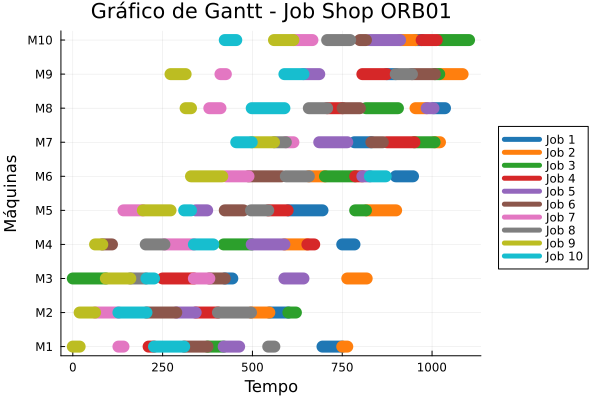

In [174]:
# ==========================================
# 4. EXIBIÇÃO DOS RESULTADOS E GANTT
# ==========================================
if termination_status(model) in [OPTIMAL, TIME_LIMIT]
    makespan_obtido = objective_value(model)
    println("\n========================================")
    println("Status do Solver: ", termination_status(model))
    println("Makespan (Cmax) obtido: ", makespan_obtido)
    println("========================================")
    
    # Geração do Gráfico de Gantt
    p = plot(title="Gráfico de Gantt - Job Shop ORB01", xlabel="Tempo", ylabel="Máquinas", 
             yticks=(1:num_machines, ["M$m" for m in 1:num_machines]), legend=:outerright)
    
    colors = palette(:tab10) # Paleta estável para 10 jobs
    
    for j in 1:num_jobs
        for o in 1:num_machines
            m = routes[j][o]
            start_time = value(t[j, m])
            duration = times[j][o]
            
            # Plota cada operação como uma barra horizontal
            plot!(p, [start_time, start_time + duration], [m, m], 
                  linewidth=12, label=o == 1 ? "Job $j" : "", color=colors[j])
        end
    end
    display(p)
else
    println("Não foi encontrada solução viável no tempo estipulado.")
end